# scikit-learn 1.9: companion notebook

## Dataset

Most examples use the [UCI Bank Marketing dataset](https://archive.ics.uci.edu/dataset/222/bank+marketing). The target, `y`, records whether a customer subscribed to a term deposit. We remove `duration` before training because it is only known after the call ends.


## Setup

Run this cell, then restart the kernel. Run it again before any other cell.


In [ ]:
%pip install -q --upgrade scikit-learn==1.9.1 ucimlrepo array-api-compat



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import sklearn

print(f"scikit-learn version: {sklearn.__version__}")
assert sklearn.__version__.startswith("1.9"), (
    "Restart the kernel, then run the setup cell again."
)


scikit-learn version: 1.9.1


In [3]:
import importlib

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.callback import ProgressBar, ScoringMonitor
from sklearn.compose import make_column_transformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score,
    metric_at_thresholds,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import utils

importlib.reload(utils)
from utils import (
    load_bank_marketing_data,
    load_penguins_data,
    make_customer_spending_data,
)


## Load the data


In [4]:
data = load_bank_marketing_data()

data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


## Check the data


In [5]:
print(f"Rows: {data.shape[0]:,}")
print(f"Columns: {data.shape[1]}")

data.info()

Rows: 45,211
Columns: 17
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  y            45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [6]:
missing_values = data.isna().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

poutcome     36959
contact      13020
education     1857
job            288
dtype: int64

,count,percentage
y,,
no,39922,88.3
yes,5289,11.7


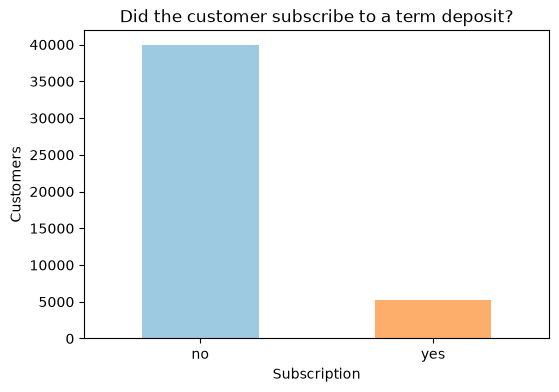

In [7]:
target_counts = data["y"].value_counts()
target_share = data["y"].value_counts(normalize=True).mul(100).round(1)

display(pd.DataFrame({"count": target_counts, "percentage": target_share}))

ax = target_counts.reindex(["no", "yes"]).plot(
    kind="bar", color=["#9ecae1", "#fdae6b"], rot=0, figsize=(6, 4)
)
ax.set_title("Did the customer subscribe to a term deposit?")
ax.set_xlabel("Subscription")
ax.set_ylabel("Customers")
plt.show()

The target is imbalanced. We will use precision, recall, and F1 alongside accuracy.


## Prepare the data

Remove `duration`, then create train, validation, and test splits. The test set is only used for the final comparison.


In [8]:
X = data.drop(columns=["y", "duration"])
y = (data["y"] == "yes").astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

numeric_features = X.select_dtypes(include="number").columns
categorical_features = X.select_dtypes(exclude="number").columns

preprocessor = make_column_transformer(
    (StandardScaler(), numeric_features),
    (OneHotEncoder(handle_unknown="ignore"), categorical_features),
)

X_train_prepared = preprocessor.fit_transform(X_train)
X_valid_prepared = preprocessor.transform(X_valid)
X_test_prepared = preprocessor.transform(X_test)

# scikit-learn 1.9 updates


The examples follow a common workflow: data handling, training, inspection, evaluation, visualization, and GPU-backed arrays.


## 1. Missing values in tree models

The examples use a small customer spending dataset with missing feature values.

### Missing values with `absolute_error`

`DecisionTreeRegressor` and `RandomForestRegressor` can now use `criterion="absolute_error"` with missing values in dense data. No imputer is needed.


In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.tree import DecisionTreeRegressor

customer_data, annual_spending = make_customer_spending_data()

X_tree_train, X_tree_test, y_tree_train, y_tree_test = train_test_split(
    customer_data, annual_spending, test_size=0.25, random_state=42
)

print("Missing values in the full dataset:")
display(customer_data.isna().sum().to_frame("missing values"))

absolute_error_models = {
    "Decision tree": DecisionTreeRegressor(
        criterion="absolute_error", max_depth=5, random_state=42
    ),
    "Random forest": RandomForestRegressor(
        criterion="absolute_error",
        n_estimators=50,
        max_depth=5,
        random_state=42,
    ),
}

absolute_error_scores = {}
for name, model in absolute_error_models.items():
    model.fit(X_tree_train, y_tree_train)
    predictions = model.predict(X_tree_test)
    absolute_error_scores[name] = mean_absolute_error(y_tree_test, predictions)

pd.Series(absolute_error_scores, name="test MAE").sort_values()


Missing values in the full dataset:


,missing values
annual_income,45
debt_ratio,41
years_with_bank,35


Random forest    2.960148
Decision tree    3.549506
Name: test MAE, dtype: float64

The models fit directly on data with missing values. Compare this approach with imputation using validation data.


### Missing values with monotonic constraints

Missing values can also be used with `monotonic_cst`. Here, `[1, -1, 1]` means that predictions increase with income and years as a customer, and decrease with debt ratio.


In [10]:
monotonic_tree = DecisionTreeRegressor(
    criterion="absolute_error",
    monotonic_cst=[1, -1, 1],
    max_depth=5,
    random_state=42,
)

monotonic_tree.fit(X_tree_train, y_tree_train)
monotonic_predictions = monotonic_tree.predict(X_tree_test)

print(
    "Test MAE:",
    round(mean_absolute_error(y_tree_test, monotonic_predictions), 3),
)


Test MAE: 3.646


The constrained tree fits without an imputer. This support is for dense `X`; `y` cannot contain missing values.


## 2. Monitor training with callbacks

`ProgressBar` shows fit progress. `ScoringMonitor` records metrics during fitting. This example monitors `neg_log_loss` and `average_precision`.

For `LogisticRegression`, callbacks require `solver="lbfgs"`. The callback API is experimental.


In [11]:
progress_bar = ProgressBar()
scoring_monitor = ScoringMonitor(scoring=["neg_log_loss", "average_precision"])

logreg = LogisticRegression(solver="lbfgs", max_iter=1000, random_state=42)
logreg.set_callbacks(progress_bar, scoring_monitor)
logreg.fit(X_train_prepared, y_train)

Output()

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

Inspect the metrics recorded during fitting.


In [12]:
log = scoring_monitor.get_logs().data_as_pandas
log[["task_name", "task_id", "neg_log_loss", "average_precision"]].head()

,task_name,task_id,neg_log_loss,average_precision
0,fit,0,-0.302507,0.395830
1,lbfgs-iter,0,-0.355754,0.186258
2,lbfgs-iter,1,-0.349168,0.209634
3,lbfgs-iter,2,-0.337891,0.262048
4,lbfgs-iter,3,-0.332971,0.278811


The same progress bar can also be attached to a grid search.


In [13]:
search_pipeline = make_pipeline(
    preprocessor,
    LogisticRegression(solver="lbfgs", max_iter=1000, random_state=42),
)

grid_search = GridSearchCV(
    search_pipeline,
    param_grid={"logisticregression__C": [0.01, 0.1, 1, 10]},
    cv=3,
    n_jobs=2,
)
grid_search.set_callbacks(ProgressBar())
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)

Output()

Best parameters: {'logisticregression__C': 0.1}


## 3. Inspect fitted estimators

After fitting, the notebook display includes a **Fitted attributes** table. Transformers also show their output features.


In [14]:
from sklearn import set_config

set_config(display="diagram")

inspection_pipeline = make_pipeline(
    preprocessor,
    LogisticRegression(solver="lbfgs", max_iter=1000, random_state=42),
)
fitted_pipeline = inspection_pipeline.fit(X_train, y_train)

display(fitted_pipeline)
display(fitted_pipeline.named_steps["columntransformer"])
display(fitted_pipeline.named_steps["logisticregression"])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['age','job','marital',...,'pdays','previous','poutcome']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('standardscaler', ...), ('onehotencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remain

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('standardscaler', ...), ('onehotencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name``

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

## 4. Inspect metrics across decision thresholds

`metric_at_thresholds` calculates a metric at every threshold where predictions can change. We use the validation set to calculate and plot accuracy, precision, and recall.


In [15]:
probabilities = logreg.predict_proba(X_valid_prepared)[:, 1]


First, view the calculated values. Then plot the same values.


In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    metric_at_thresholds,
)

accuracy, thresholds = metric_at_thresholds(y_valid, probabilities, accuracy_score)
precision, _ = metric_at_thresholds(y_valid, probabilities, precision_score)
recall, _ = metric_at_thresholds(y_valid, probabilities, recall_score)

metrics_by_threshold = pd.DataFrame(
    {
        "threshold": thresholds,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
    }
).sort_values("threshold", ignore_index=True)

metrics_by_threshold


,threshold,accuracy,precision,recall
0,0.000390,0.117010,0.117010,1.000000
1,0.000933,0.117120,0.117022,1.000000
2,0.001792,0.117231,0.117035,1.000000
3,0.003471,0.117120,0.116938,0.999055
4,0.004239,0.117231,0.116951,0.999055
...,...,...,...,...
9035,0.908826,0.883101,0.600000,0.002836
9036,0.913850,0.883212,0.750000,0.002836
9037,0.914275,0.883101,0.666667,0.001890
9038,0.918696,0.882990,0.500000,0.000945


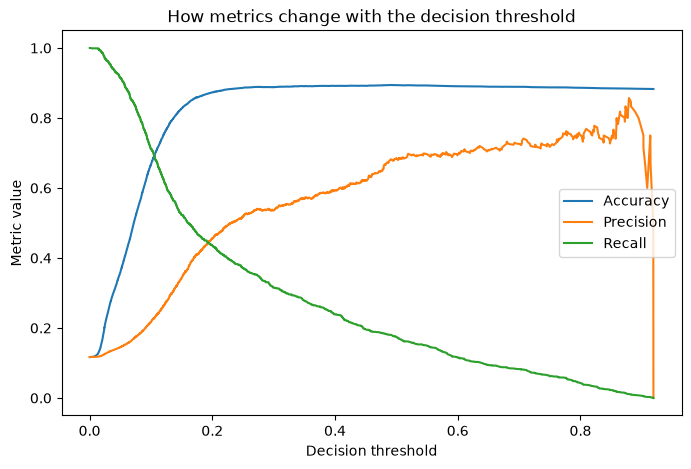

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(
    metrics_by_threshold["threshold"],
    metrics_by_threshold["accuracy"],
    label="Accuracy",
)
plt.plot(
    metrics_by_threshold["threshold"],
    metrics_by_threshold["precision"],
    label="Precision",
)
plt.plot(
    metrics_by_threshold["threshold"],
    metrics_by_threshold["recall"],
    label="Recall",
)
plt.xlabel("Decision threshold")
plt.ylabel("Metric value")
plt.title("How metrics change with the decision threshold")
plt.legend()
plt.show()


Compare the default threshold with the threshold that gives the highest validation accuracy. Use the test set only for this final comparison.


In [18]:
best_threshold = thresholds[accuracy.argmax()]
test_probabilities = logreg.predict_proba(X_test_prepared)[:, 1]

default_predictions = (test_probabilities >= 0.5).astype(int)
selected_predictions = (test_probabilities >= best_threshold).astype(int)

comparison = pd.DataFrame(
    {
        "threshold": [0.5, best_threshold],
        "precision": [
            precision_score(y_test, default_predictions),
            precision_score(y_test, selected_predictions),
        ],
        "recall": [
            recall_score(y_test, default_predictions),
            recall_score(y_test, selected_predictions),
        ],
        "f1": [
            f1_score(y_test, default_predictions),
            f1_score(y_test, selected_predictions),
        ],
    },
    index=["Default threshold", "Best validation accuracy"],
)
comparison.round(3)

,threshold,precision,recall,f1
Default threshold,0.500,0.713,0.185,0.294
Best validation accuracy,0.491,0.697,0.189,0.297


Choose a threshold based on the cost of errors in the use case.


## 5. More accessible multiclass decision boundaries

The Palmer Penguins dataset has three species. We use bill length and bill depth to plot a multiclass decision boundary.

In version 1.9, `DecisionBoundaryDisplay` uses the accessible Petroff colour sequence by default for multiclass plots with up to ten classes. We use the same colours for the points and decision regions.


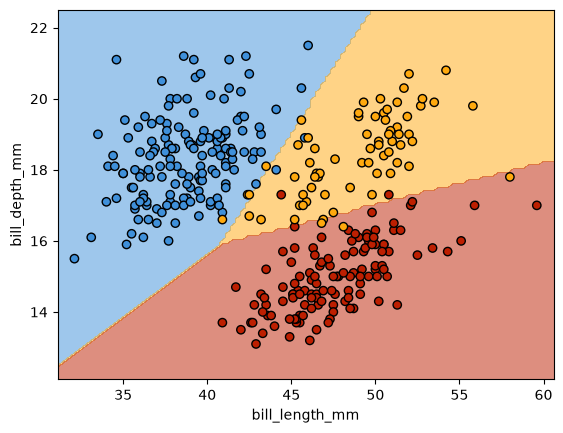

In [19]:
import importlib
import utils

importlib.reload(utils)
from utils import load_penguins_data

import matplotlib.pyplot as plt
import pandas as pd
import sklearn
from matplotlib.colors import ListedColormap
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.linear_model import LogisticRegression

assert sklearn.__version__.startswith("1.9")

penguins = load_penguins_data()
plot_data = penguins[["bill_length_mm", "bill_depth_mm", "species"]].dropna()

X_penguins = plot_data[["bill_length_mm", "bill_depth_mm"]]
y_penguins = pd.Categorical(plot_data["species"]).codes

model = LogisticRegression(max_iter=300).fit(X_penguins, y_penguins)

disp = DecisionBoundaryDisplay.from_estimator(
    model,
    X_penguins,
    response_method="predict",
    alpha=0.5,
)

disp.ax_.scatter(
    X_penguins.iloc[:, 0],
    X_penguins.iloc[:, 1],
    c=y_penguins,
    cmap=ListedColormap(disp.multiclass_colors_),
    edgecolor="black",
)
plt.show()


## 6. More Array API support

Array API dispatch lets supported scikit-learn operations work directly with compatible arrays, such as PyTorch tensors on a GPU. The feature is experimental.

Run the next cell, restart the kernel, then run this section. `SCIPY_ARRAY_API` must be set before scikit-learn is imported.

Here, `LogisticRegression` with `solver="lbfgs"` fits directly on CUDA tensors. `cuda:0` confirms that the predictions and learned coefficients remain on the first GPU.


In [ ]:
import os

# Enable Array API support before importing scikit-learn
os.environ["SCIPY_ARRAY_API"] = "1"


In [ ]:
import torch
from sklearn import config_context
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression

if not torch.cuda.is_available():
    raise RuntimeError("This example requires a CUDA GPU.")

X_np, y_np = make_classification(
    n_samples=1_000,
    n_features=20,
    n_informative=10,
    random_state=42,
)

X_torch = torch.asarray(X_np, dtype=torch.float32, device="cuda")
y_torch = torch.asarray(y_np, dtype=torch.int64, device="cuda")

with config_context(array_api_dispatch=True):
    model = LogisticRegression(solver="lbfgs", max_iter=500).fit(
        X_torch, y_torch
    )
    predictions = model.predict(X_torch)

print("Prediction device:", predictions.device)
print("Coefficient device:", model.coef_.device)


## Further reading

See the [scikit-learn 1.9 release notes](https://scikit-learn.org/1.9/whats_new/v1.9.html) for all changes and supported estimators.
